In [1]:
from maze import *

env = Maze()
env.snum   # 112
env.anum   # 4
env.slip   # 0.1
initial_state = env.reset()
state = initial_state

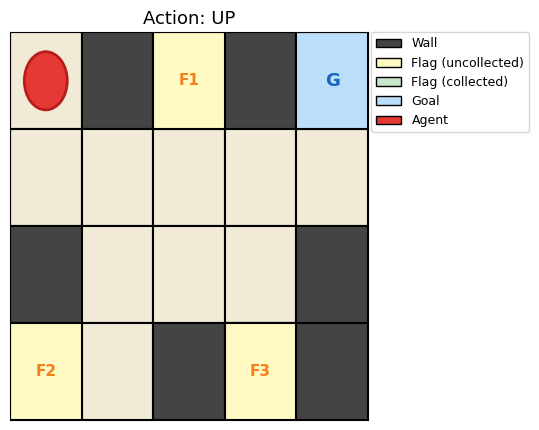

In [2]:
import numpy as np

action = np.random.choice(4,)
reward, state, done = env.step(state, action)
env.plot(state, action)
if done:
    print("Episode finished")

In [3]:
import numpy as np

state_values = np.zeros(env.snum)  # One scalar value per state

In [4]:
def get_expected_reward_and_next_state(state, action):
    """Returns (expected_reward, expected_next_state_value) under the slip model."""
    slip_chance = env.slip

    # Intended transition
    env.slip = 0.0
    reward, next_state, _ = env.step(state, action)
    env.slip = slip_chance

    # Slip transition
    env.slip = 1.0
    reward_slip, next_state_slip, _ = env.step(state, action)
    env.slip = slip_chance

    expected_reward = reward * (1 - slip_chance) + reward_slip * slip_chance
    expected_next_value = state_values[next_state] * (1 - slip_chance) + state_values[next_state_slip] * slip_chance

    return expected_reward, expected_next_value

def bellman_equation(state, action_space=[0, 1, 2, 3], discount_factor=0.9):
    """
    V(s) = max_a [ R(s, a) + γ * Σ P(s'|s,a) * V(s') ]
    """
    action_values = np.zeros(len(action_space))

    for action in action_space:
        expected_reward, expected_next_value = get_expected_reward_and_next_state(state, action)
        action_values[action] = expected_reward + discount_factor * expected_next_value

    return np.max(action_values)

In [5]:
# Iterate through all states
for i in range(100):  # Arbitrary number of iterations for convergence
    og_state_values = state_values.copy()

    for s in range(env.snum):
        state_values[s] = bellman_equation(s)

    # Check for convergence
    if np.max(np.abs(state_values - og_state_values)) < 1e-4:
        print(f"Converged! at iteration {i}")
        break

Converged! at iteration 98


In [6]:
state_values

array([ 5.29154352,  6.88117416,  8.6305681 ,  8.40259351, 11.13651134,
       10.73369591, 12.689479  , 16.08415723,  5.94486582,  7.73075343,
        9.69613015,  9.44000722, 12.51145813, 12.05890718, 14.25616484,
       18.06995085,  7.00435495, 10.18606077,  7.78266023, 10.28471249,
       11.31790774, 13.05671877, 11.42751912, 14.50753477,  6.67884519,
        8.68521903, 10.89324306, 10.60549669, 14.05615144, 13.54772477,
       16.01626869, 20.30090417,  6.12703201,  9.6637964 ,  9.82298408,
        9.54502877, 14.28504053, 12.360445  , 14.42338486, 18.31085431,
        6.85538767, 10.03724695,  8.74353096, 10.11534307, 12.71524968,
       12.86354322, 12.8383915 , 16.29866565,  7.64460672,  8.58843678,
       12.49130991, 12.16342589, 14.03351487, 13.66514757, 18.24513884,
       20.49772135,  7.56475187,  9.64878907, 12.35706535, 12.03270351,
       15.7661155 , 15.35226698, 18.17065641, 23.02840047,  6.80256864,
       10.81541605, 11.10512879, 10.60645083, 16.22312407, 13.83